In [ ]:
from rocketpy import Environment, SolidMotor, Rocket, Flight
import datetime
import math

tomorrow = datetime.date.today() + datetime.timedelta(days=1)

env = Environment(latitude=28.0, longitude=-82.0, elevation=10)
env.set_date(
    (tomorrow.year, tomorrow.month, tomorrow.day, 12)
)  # Hour given in UTC time
env.set_atmospheric_model(type="Forecast", file="GFS")

**BUILDING THE MOTOR**

In [16]:
M1939W = SolidMotor(
    thrust_source="AeroTech_M1939W.eng",
    dry_mass=3.33,  # kg
    dry_inertia=(0.148, 0.148, 0.00392),
    nozzle_radius=0.009325,  # m
    grain_number=4,
    grain_density=1709,  # kg/m3
    grain_outer_radius=0.0427355,  # m
    grain_initial_inner_radius=0.0142875,  # m
    grain_initial_height=0.1524,  # m
    grain_separation=0.01,  # m
    grains_center_of_mass_position=0.366,  # m
    center_of_dry_mass_position=0.366,  # m
    nozzle_position=0,
    burn_time=6.23,  # s
    coordinate_system_orientation="nozzle_to_combustion_chamber",
)

**BUILDING THE ROCKET**

In [17]:
I = (4.656,4.656,0.088)  # kg*m2

rocket = Rocket(
    radius=0.157/2, # m
    mass=18.3,  # kg
    inertia= I, #(4.656,4.656,0.088), kg*m2
    power_off_drag="Cd_vs_Mach_openrocket_clean.csv",
    power_on_drag="Cd_vs_Mach_openrocket_clean.csv",
    center_of_mass_without_motor=1.65,  # m
    coordinate_system_orientation="nose_to_tail",
)

rocket.add_motor(M1939W,position=2.9)

**ADDING NOSE CONE**

In [18]:
nose_cone=rocket.add_nose(
    length=0.762, kind="lvhaack", position=0.0
)

**ADDING THE FINS**

In [19]:
fin_set=rocket.add_trapezoidal_fins(
    n=4,
    root_chord=0.356,
    tip_chord=0.051,
    span=0.178,
    position=2.49,
    cant_angle=0,
    sweep_angle=55
)

**ADDING PARCHUTES**

In [20]:
main = rocket.add_parachute(
    name="main",
    cd_s=9.77,
    trigger=304.8,      # ejection altitude in meters
    sampling_rate=105,
    lag=1.5,
    noise=(0, 8.3, 0.5),
)

drogue = rocket.add_parachute(
    name="drogue",
    cd_s=0.293,
    trigger="apogee",  # ejection at apogee
    sampling_rate=105,
    lag=1.5,
    noise=(0, 8.3, 0.5),
)

**CREATING TEST LAUNCH**

In [21]:
test_flight = Flight(
    rocket=rocket, environment=env, rail_length=5.18, inclination=7, heading=0
    )

**CALLING ON SIMULATION FUNCTIONS**

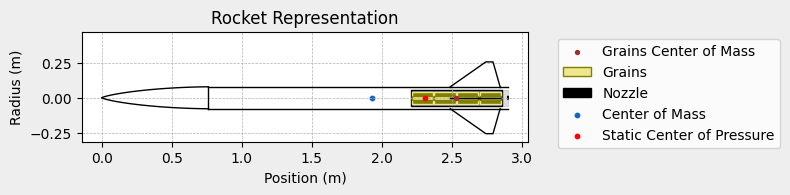


Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 44.86 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: 0.749 | e1: -0.663 | e2: 0.000 | e3: 0.000
Euler Angles - Spin φ : 0.00° | Nutation θ: -83.00° | Precession ψ: 0.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 2.381 c


Surface Wind Conditions

Frontal Surface Wind Speed: -0.89 m/s
Lateral Surface Wind Speed: 2.04 m/s


Launch Rail

Launch Rail Length: 5.18 m
Launch Rail Inclination: 7.00°
Launch Rail Heading: 0.00°


Rail Departure State

Rail Departure Time: 0.448 s
Rail Departure Velocity: 27.388 m/s
Rail Departure Stability Margin: 2.438 c
Rail Departure Angle of Attack: 4.124°
Rail Departure Thrust-Weight Ratio: 7.806
Rail Departure Reynolds Number: 2.930e+05


Burn out State

Burn out time: 6.230 s
Altitude at burn out: 44.859 m (ASL) | -0.000 m (AGL)
Rocket speed at burn out: 0.000 m/s
Freestream velocity at 

In [23]:
#rocket.all_info()
#rocket.plots.static_margin()
rocket.draw()
test_flight.info()